Burgers’ equation is an important and basic partial differential equation from fluid mechanics. This equation combines the characteristics of the first order wave equation and heat conduction equation, and is used as a tool to describe the interaction between convection and diffusion. For more details see, for example, [this source](https://www.iist.ac.in/sites/default/files/people/IN08026/Burgers_equation_viscous.pdf).

Burgers' Equation for Horizontal Velocity (u):

\begin{equation}
    \begin{split}
        \frac{\partial u}{\partial t} + \underbrace{u \frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y}}_\text{convection terms} \quad &= \quad \nu \Bigg( \underbrace{\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}}_\text{diffusion terms} \Bigg)
    \end{split}
\end{equation}


Burgers' Equation for Vertical Velocity (v)

\begin{equation}
    \begin{split}
        \frac{\partial v}{\partial t} + u \frac{\partial v}{\partial x} + v \frac{\partial v}{\partial y} \quad &= \quad \nu \Bigg( \frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2} \Bigg) \tag{2}
    \end{split}
\end{equation}


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Setup
# Ranges / upper bounds
nt = 500        # upper bound t
nx = 51         # upper bound x 
ny = 51         # upper bound y

# Step sizes
nu = 0.1        # diffusion term nü
dt = .001       # time step size

x_domain_max = 2
y_domain_max = 2

# Differentials
dx = x_domain_max/(nx-1)   # Domain from 1 to 2
dy = y_domain_max/(ny-1)

In [3]:

x = np.linspace(0, x_domain_max, nx)
y = np.linspace(0, y_domain_max, ny)

print('Create grid with %s steps and step size %s:' % (nx-1, x_domain_max/(nx-1)))
x

Create grid with 50 steps and step size 0.04:


array([0.  , 0.04, 0.08, 0.12, 0.16, 0.2 , 0.24, 0.28, 0.32, 0.36, 0.4 ,
       0.44, 0.48, 0.52, 0.56, 0.6 , 0.64, 0.68, 0.72, 0.76, 0.8 , 0.84,
       0.88, 0.92, 0.96, 1.  , 1.04, 1.08, 1.12, 1.16, 1.2 , 1.24, 1.28,
       1.32, 1.36, 1.4 , 1.44, 1.48, 1.52, 1.56, 1.6 , 1.64, 1.68, 1.72,
       1.76, 1.8 , 1.84, 1.88, 1.92, 1.96, 2.  ])

In [4]:
comb = np.zeros((ny,nx))
comb

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [5]:
# Shape : (ny, nx)
comb.shape

(51, 51)

In [6]:
# Create placeholders for time steps etc. since we are using an explicit method (calculating every time step)

u = np.zeros((ny, nx))      # current time step
v = np.zeros((ny, nx))      # current time step

un = np.zeros((ny, nx))     # previous time steps' values
vn = np.zeros((ny, nx))     # previous time steps' values

uf = np.zeros((nt, ny, nx)) # placeholder for the solution 
vf = np.zeros((nt, ny, nx)) # placeholder for the solution

print(u.shape)
print(uf.shape)

(51, 51)
(500, 51, 51)


In [7]:

# Set Initial Conditions 
u = np.ones((ny, nx))
v = np.ones((ny, nx))
uf = np.ones((nt, ny, nx))
vf = np.ones((nt, ny, nx))


# Actual calculations for u, v, uf and uv
# u[x , y]
u[int(0.75/dy):int(1.25/dy+1) , int(0.75/dy):int(1.25/dy+1)] = 5    # Interval [0.75,1.25] region of high speed
# v[x , y]
v[int(0.75/dy):int(1.25/dy+1) , int(0.75/dy):int(1.25/dy+1)] = 5

# uf[t, x, y]
uf[0 ,int(0.75/dy):int(1.25/dy+1) , int(0.75/dy):int(1.25/dy+1)] = 5
# vf[t, x, y]
vf[0 ,int(0.75/dy):int(1.25/dy+1) , int(0.75/dy):int(1.25/dy+1)] = 5

In [8]:
def plot_grid(x, y, func):
    X, Y = np.meshgrid(x, y)

    plt.figure(figsize=(4,3))
    contour = plt.contourf(X, Y, func, cmap='jet')
    plt.title("Solution")
    plt.xlabel("X")
    plt.ylabel("Y")
    colorbar = plt.colorbar(contour)
    colorbar.set_label("Scale")

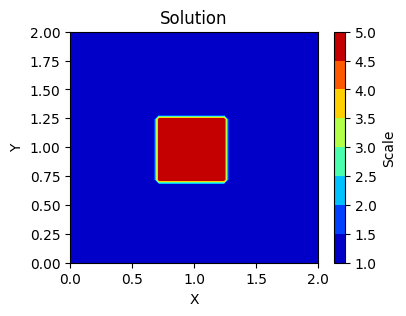

In [9]:
# u solution & scale
plot_grid(x, y, u[:])

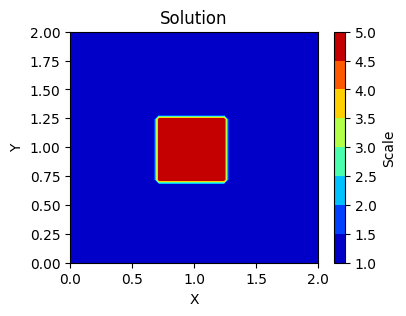

In [10]:
# v solution & scale
plot_grid(x, y, v[:])

In [11]:
# Take constant terms oout of the loop to enhance performance
dt_dx = dt/dx
nu_dt_dx = (nu*dt/(dx**2))
dt_dy = dt/dx
# no nu_dt_dy?

# Update Burgers equation in every time step
for n in range(1, nt):
    un = u.copy()       # save last time step
    vn = v.copy()
    # Iterate through mesh
    for i in range(1, nx-1):
        for j in range(1, ny-1):
            un_i_j = un[i,j]
            vn_i_j = vn[i,j]

            # Original code
#            u[i,j] = (un[i,j] - (un[i,j]*dt/dx*(un[i,j]-un[i-1,j]))-vn[i,j]*dt/dy*(un[i,j]-un[i,j-1])) + (nu*dt/(dx**2))*(un[i+1,j]-2*un[i,j]+un[i-1,j]) + (nu*dt/(dx**2))*(un[i,j-1]-2*un[i,j]+un[i,j+1])
            # Enhanced code with substituted constant terms
            u[i,j] = (un_i_j - (un_i_j*dt_dx*(un_i_j-un[i-1,j]))-vn_i_j*dt_dy*(un_i_j-un[i,j-1])) + nu_dt_dx*(un[i+1,j]-2*un_i_j+un[i-1,j]) + nu_dt_dx*(un[i,j-1]-2*un_i_j+un[i,j+1])

#            v[i,j] = (vn[i,j] - (un[i,j]*dt/dx*(vn[i,j]-vn[i-1,j]))-vn[i,j]*dt/dy*(vn[i,j]-vn[i,j-1])) + (nu*dt/(dx**2))*(vn[i+1,j]-2*vn[i,j]+vn[i-1,j]) + (nu*dt/(dx**2))*(vn[i,j-1]-2*vn[i,j]+vn[i,j+1])
            v[i,j] = (vn_i_j - (un_i_j*dt_dx*(vn_i_j-vn[i-1,j]))-vn_i_j*dt_dy*(vn_i_j-vn[i,j-1])) + nu_dt_dx*(vn[i+1,j]-2*vn_i_j+vn[i-1,j]) + nu_dt_dx*(vn[i,j-1]-2*vn_i_j+vn[i,j+1])
            uf[n,i,j] = u[i,j]
            vf[n,i,j] = v[i,j]
    
    # Update boundary conditions
    u[:, 0] = 1     # all rows of first col
    u[:,-1] = 1     # all rows of last col
    u[ 0,:] = 1     # all col in first row 
    u[-1,:] = 1     # all col in last row
    v[:, 0] = 1
    v[:,-1] = 1
    v[ 0,:] = 1
    v[-1,:] = 1        

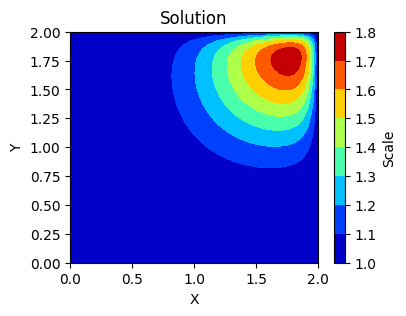

In [12]:
# u solution
plot_grid(x, y, u[:])

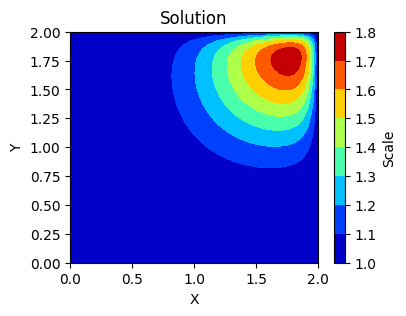

In [13]:
# u solution
plot_grid(x, y, v[:])

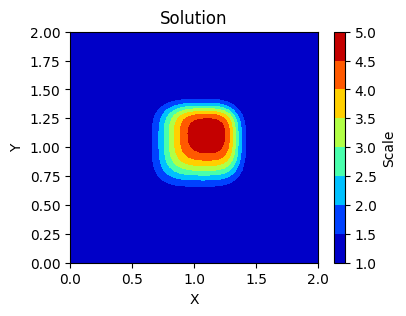

In [17]:
# Set the time as you like

#     [t, x, y]
u = uf[30, :, :]          # Check how graph converges for different t for t in [0, 499]

# u solution
plot_grid(x, y, u)